# Automatic Differentiation Through `jact`

This notebook shows a minimal end-to-end sensitivity calculation through the solver. We compute a terminal present value for an annuity paid while alive, then differentiate that present value with respect to a mortality-intensity parameter.

The example is intentionally small:

1. build a two-state `alive -> dead` model,
2. define a present-value cashflow view,
3. wrap the solve in a scalar objective,
4. apply `jax.grad`.

Because the solver is JAX-native, the same solve can be used both for valuation and for automatic differentiation.

In [1]:
import jact
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## A differentiable mortality parameter

We use one transition, `alive -> dead`, with a constant hazard level supplied at solve time as the covariate `mortality_level`. That makes the sensitivity target explicit: the output changes only because the transition intensity changes.

In [2]:
state_space = jact.StateSpace(
    states=["alive", "dead"],
    transitions=[("alive", "dead")],
)


def mortality_intensity(t, d, *, mortality_level):
    return mortality_level[:, None] + jnp.zeros_like(d)


model = state_space.build(
    transitions={("alive", "dead"): mortality_intensity}
)

print(state_space)
print(model.info("alive", "dead"))

StateSpace(states=['alive', 'dead'], transitions=[alive->dead])
TransitionInfo(source='alive', target='dead', assignment='transitions', callable=<function mortality_intensity at 0x7f243f483560>, index=None)


## Cashflows and terminal present value

The cashflow is a level annuity paid while the policyholder remains alive. We discount each step by `exp(-r t)` and request a terminal `Total(...)` view so the solver returns one present value per batch element.

In [3]:
HORIZON = 20
STEPS_PER_UNIT = 96
DISCOUNT_RATE = 0.03
ANNUITY_RATE = 1_000.0


def alive_annuity(t, d, *, mortality_level):
    return jnp.full((mortality_level.shape[0], d.shape[-1]), ANNUITY_RATE)


def discount_weight(t, **kwargs):
    return jnp.exp(-DISCOUNT_RATE * t)


cashflows = state_space.cashflows(
    {
        "annuity": jact.StateRate({"alive": alive_annuity}),
    }
)


def present_value(mortality_level_scalar):
    result = model.solve(
        initial="alive",
        horizon=HORIZON,
        steps_per_unit=STEPS_PER_UNIT,
        record_every=12,
        probability=None,
        cashflows=cashflows,
        cashflow_views={
            "pv": jact.Total(weight=discount_weight, terminal=True),
        },
        mortality_level=jnp.array([mortality_level_scalar], dtype=jnp.float32),
    )
    return result.cashflows["pv"][0]


present_value_grad = jax.grad(present_value)

## Differentiate the solver output

For an annuity paid while alive, higher mortality should reduce present value. The derivative with respect to the mortality level should therefore be negative in this setup.

In [8]:
base_mortality = jnp.array(0.02, dtype=jnp.float32)

pv = present_value(base_mortality)
dpv_dlambda = present_value_grad(base_mortality)

print(f"PV at mortality {float(base_mortality):.4f} = {float(pv):.2f}")
print(f"dPV / d mortality_level = {float(dpv_dlambda):.2f}")

PV at mortality 0.0200 = 12642.41
dPV / d mortality_level = -105696.15


## Sweep the parameter

We can evaluate both the present value and its gradient over a grid with `jax.vmap`. This gives a compact sensitivity curve without changing the model structure.

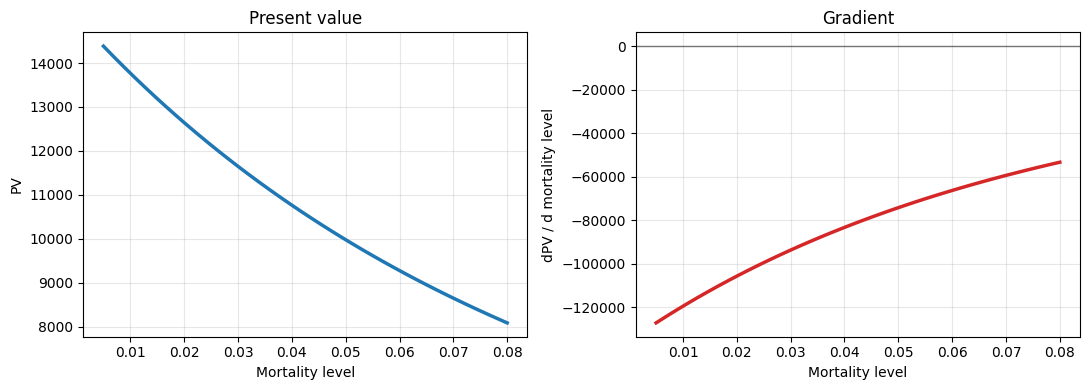

In [9]:
mortality_grid = jnp.linspace(0.005, 0.08, 40, dtype=jnp.float32)
pv_grid = jax.vmap(present_value)(mortality_grid)
grad_grid = jax.vmap(present_value_grad)(mortality_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(mortality_grid, pv_grid, linewidth=2.5)
axes[0].set_title("Present value")
axes[0].set_xlabel("Mortality level")
axes[0].set_ylabel("PV")
axes[0].grid(alpha=0.3)

axes[1].plot(mortality_grid, grad_grid, linewidth=2.5, color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
axes[1].set_title("Gradient")
axes[1].set_xlabel("Mortality level")
axes[1].set_ylabel("dPV / d mortality level")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Notes

- The differentiated quantity is the same public `model.solve(...)` result you would use for ordinary valuation.
- No custom adjoint code is needed; `jax.grad` works directly on the scalar present-value wrapper.
- The solver internally checkpoints recorded blocks, so reverse-mode differentiation remains compatible with long solves without retaining every inner step in memory.